# E-Commerce Sales Performance Analysis

## Business Problem
The company wants to understand sales performance, customer behavior, product trends, and regional performance.

## Objective
Perform Exploratory Data Analysis (EDA) and generate actionable business insights.


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')




In [64]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")


In [65]:
datasets = {
    "customers": customers,
    "orders": orders,
    "items": items,
    "products": products,
    "payments": payments,
    "reviews": reviews,
    "sellers": sellers
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.shape)
    print(df.info())


CUSTOMERS
(99441, 5)
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

ORDERS
(99441, 8)
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  s

In [66]:
for name, df in datasets.items():
    print("\n", name)
    print(df.isnull().sum())


 customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

 items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm    

In [67]:
for name, df in datasets.items():
    print(name, df.duplicated().sum())

customers 0
orders 0
items 0
products 0
payments 0
reviews 0
sellers 0


In [68]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [69]:
products = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

merged = orders.merge(customers,on='customer_id')
merged = merged.merge(items,on='order_id')
merged = merged.merge(products,on='product_id')
merged = merged.merge(payments,on='order_id')

In [70]:
merged.to_csv(
    "cleaned_merged_dataset.csv",
    index=False
)

# Question 1: Which Product Categories Generate the Highest Revenue?

In [71]:
merged['revenue'] = merged['price']

category_revenue = merged.groupby(
    'product_category_name_english'
)['revenue'].sum().sort_values(
    ascending=False
)

print(category_revenue.head(10))



product_category_name_english
health_beauty            1297355.80
watches_gifts            1253143.30
bed_bath_table           1092551.02
sports_leisure           1023996.34
computers_accessories     942277.57
furniture_decor           765093.89
housewares                666587.00
cool_stuff                662309.49
auto                      616752.51
garden_tools              518217.54
Name: revenue, dtype: float64


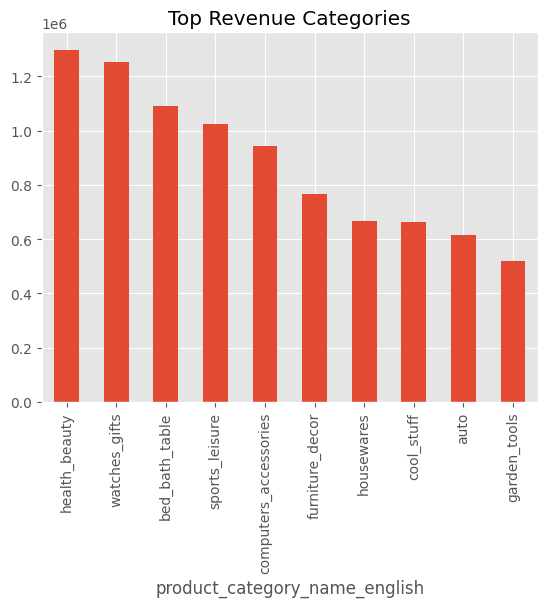

In [72]:
category_revenue.head(10).plot(kind='bar')
plt.title("Top Revenue Categories")
plt.show()

Insight:
The top categories generate the majority of revenue.
The company should focus marketing efforts on these categories.


# Question 2: Which Cities Contribute the Most Sales?



In [73]:
city_sales = merged.groupby(
    'customer_city'
)['revenue'].sum().sort_values(
    ascending=False
)

print(city_sales.head(10))

customer_city
sao paulo         2008254.39
rio de janeiro    1030715.84
belo horizonte     366981.33
brasilia           312274.57
curitiba           218532.47
salvador           196675.55
porto alegre       195635.58
campinas           195626.49
guarulhos          155216.85
niteroi            132616.38
Name: revenue, dtype: float64


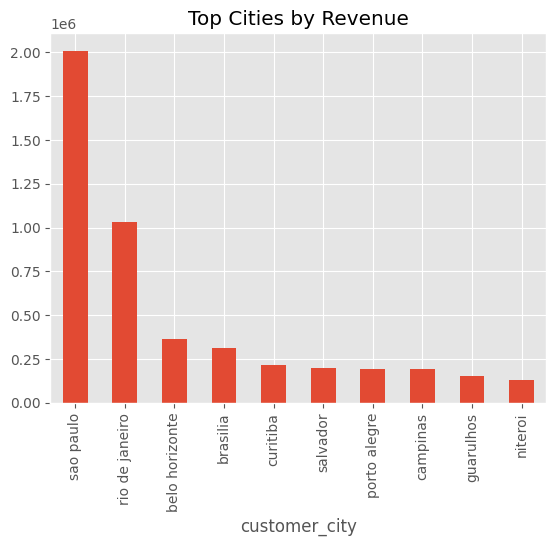

In [74]:
city_sales.head(10).plot(kind='bar')
plt.title("Top Cities by Revenue")
plt.show()

Insight:
A few cities contribute a large share of total sales.
These markets should receive additional business focus.


# Question 3: Which Customer Segments Provide Highest Business Value?

In [75]:
customer_value = merged.groupby(
    "customer_unique_id"
)["revenue"].sum().sort_values(
    ascending=False
)

customer_value.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13440.00
8af7ac63b2efbcbd88e5b11505e8098a    11383.95
c4b224d2c784bae11ae98b6ae9f2454c    10856.10
85963fd37bfd387aa6d915d8a1065486     9888.00
be74c431147c32ab2d7c7cef5e4a995f     9520.14
edf81e1f3070b9dac83ec83dacdbb9bc     7998.00
1033eef37a760a832f9b2332ce23fdc5     7799.40
58483a1c055dfb600f57c5b867174542     7798.00
da122df9eeddfedc1dc1f5349a1a690c     7388.00
763c8b1c9c68a0229c42c9fc6f662b93     7160.00
Name: revenue, dtype: float64

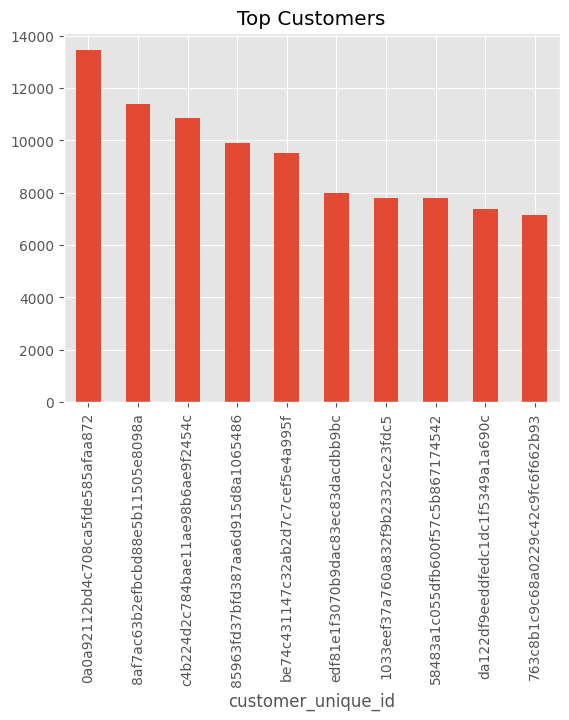

In [76]:
customer_value.head(10).plot(kind="bar")
plt.title("Top Customers")
plt.show()

# Question 4
## What Purchasing Patterns Can Be Observed?


In [77]:
orders["month"] = orders[
    "order_purchase_timestamp"
].dt.month

monthly_orders = orders.groupby(
    "month"
)["order_id"].count()

monthly_orders


month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: order_id, dtype: int64

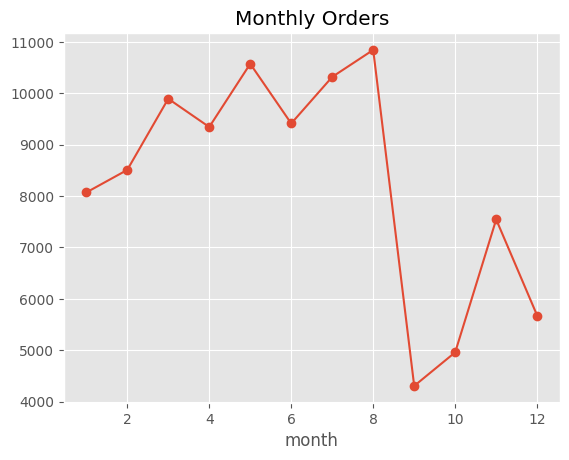

In [78]:
monthly_orders.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Orders")
plt.show()


# Question 5
## Which Products Show Highest Sales Volume and Revenue?



In [79]:
product_sales = merged.groupby(
    "product_id"
)["revenue"].sum().sort_values(
    ascending=False
)

product_sales.head(10)


product_id
bb50f2e236e5eea0100680137654686c    68485.00
d6160fb7873f184099d9bc95e30376af    56948.83
6cdd53843498f92890544667809f1595    55779.90
d1c427060a0f73f6b889a5c7c61f2ac4    49141.40
99a4788cb24856965c36a24e339b6058    46308.96
25c38557cf793876c5abdd5931f922db    44829.32
3dd2a17168ec895c781a9191c1e95ad7    41682.20
aca2eb7d00ea1a7b8ebd4e68314663af    38248.20
53b36df67ebb7c41585e8d54d6772e08    38158.21
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
Name: revenue, dtype: float64

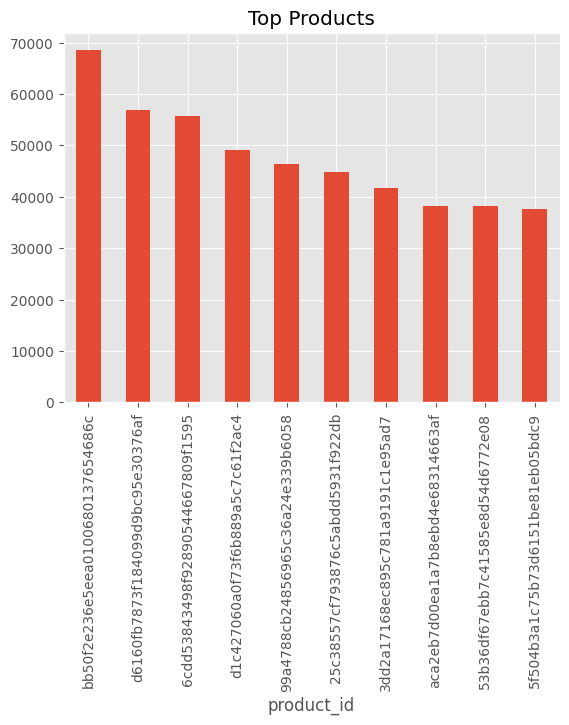

In [80]:
product_sales.head(10).plot(
    kind="bar"
)

plt.title("Top Products")
plt.show()

# Question 6
## How Do Payment Methods Influence Purchasing Trends?

In [81]:
payment_summary = payments.groupby(
    "payment_type"
)["payment_value"].sum()

payment_summary


payment_type
boleto          2869361.27
credit_card    12542084.19
debit_card       217989.79
not_defined           0.00
voucher          379436.87
Name: payment_value, dtype: float64

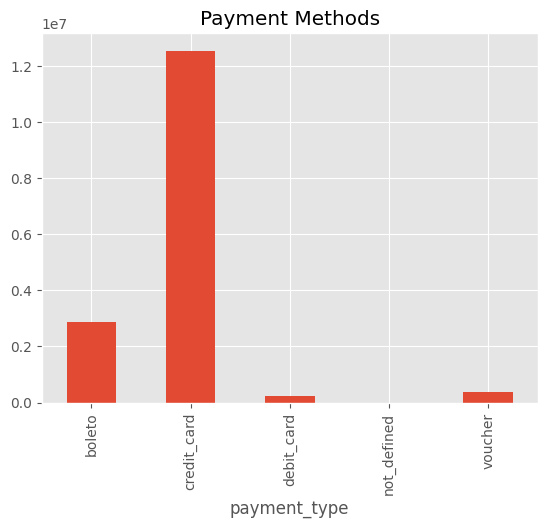

In [82]:
payment_summary.plot(kind="bar")
plt.title("Payment Methods")
plt.show()

# Question 7
## Which Sellers Contribute the Most Value?

In [83]:
seller_revenue = merged.groupby(
    "seller_id"
)["revenue"].sum().sort_values(
    ascending=False
)

seller_revenue.head(10)

seller_id
53243585a1d6dc2643021fd1853d8905    244627.55
4869f7a5dfa277a7dca6462dcf3b52b2    237867.23
4a3ca9315b744ce9f8e9374361493884    213299.57
fa1c13f2614d7b5c4749cbc52fecda94    203984.22
7c67e1448b00f6e969d365cea6b010ab    198194.33
7e93a43ef30c4f03f38b393420bc753a    182878.17
da8622b14eb17ae2831f4ac5b9dab84a    169297.77
7a67c85e85bb2ce8582c35f2203ad736    149939.84
1025f0e2d44d7041d6cf58b6550e0bfa    142130.94
955fee9216a65b617aa5c0531780ce60    137335.00
Name: revenue, dtype: float64

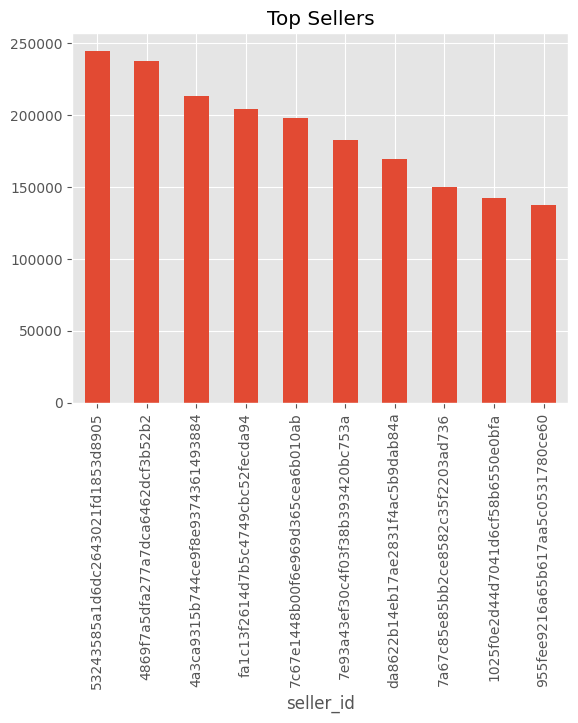

In [84]:
seller_revenue.head(10).plot(
    kind="bar"
)

plt.title("Top Sellers")
plt.show()

# Question 8
## How Do Review Scores Vary Across Categories?

In [85]:
review_data = merged.merge(
    reviews,
    on="order_id"
)

review_summary = review_data.groupby(
    "product_category_name_english"
)["review_score"].mean()

review_summary.sort_values(
    ascending=False
).head(10)

product_category_name_english
cds_dvds_musicals                        4.642857
fashion_childrens_clothes                4.500000
books_general_interest                   4.438503
books_imported                           4.419355
flowers                                  4.419355
costruction_tools_tools                  4.415842
books_technical                          4.375465
food_drink                               4.324138
small_appliances_home_oven_and_coffee    4.320513
luggage_accessories                      4.295945
Name: review_score, dtype: float64

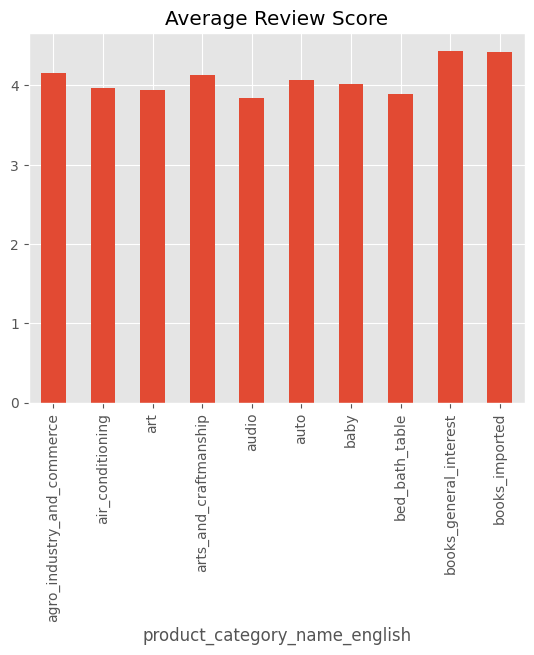

In [86]:
review_summary.head(10).plot(
    kind="bar"
)

plt.title("Average Review Score")
plt.show()

# Question 9
## What Happens to Sales Volume Across Time Periods?

In [87]:
orders["year_month"] = orders[
    "order_purchase_timestamp"
].dt.to_period("M")

sales_trend = orders.groupby(
    "year_month"
)["order_id"].count()

sales_trend

year_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

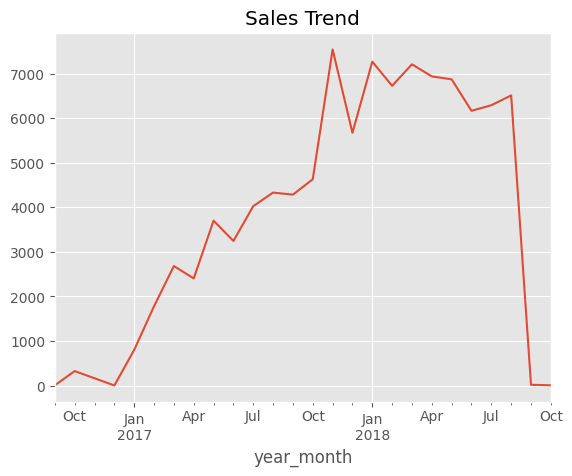

In [88]:
sales_trend.plot(kind="line")

plt.title("Sales Trend")
plt.show()

# Question 10
## Which Customers Are Repeat Versus One-Time?

In [89]:
repeat = merged.groupby(
    "customer_unique_id"
)["order_id"].nunique()

repeat_customers = repeat[
    repeat > 1
]

print(
    "Repeat Customers:",
    len(repeat_customers)
)

Repeat Customers: 2913


# Question 11
## What Data Quality Issues Appear in the Merged Dataset?

In [90]:
print(merged.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1698
product_name_lenght              1698
product_description_lenght       1698
product_photos_qty               1698
product_weight_g                   20
product_length_cm                  20
product_height_cm                  20
product_width_cm                   20
product_cate

In [91]:
print(
    "Duplicates:",
    merged.duplicated().sum()
)

Duplicates: 0


# Question 12
## How Reliable Is the Merge Across Multiple Files?

In [92]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Merged:", merged.shape)


Orders: (99441, 10)
Customers: (99441, 5)
Merged: (117601, 32)


In [93]:
print(
    merged["customer_id"]
    .isnull()
    .sum()
)

0


# Final Conclusion

## Key Findings

1. Highest Revenue Categories
2. Top Revenue Cities
3. Most Valuable Customers
4. Most Preferred Payment Method
5. Top Sellers
6. Sales Trends
7. Repeat Customer Analysis

## Recommendations

- Invest more in top-performing categories.
- Focus marketing in high-revenue cities.
- Reward loyal customers.
- Improve low-rated product categories.
- Support top-performing sellers.